In [1]:
import sys
import os
import torch
import torchvision.transforms as transforms

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:    
    sys.path.append(project_root)
from src.my_app.core.MyDataset.OldMyDataset_speed import PreTrainDataset_old
from src.my_app.core.MyDataset import PreTrainDataset_v2
import multiprocessing as mp

In [2]:
# --- Dataset ---
transform = transforms.Compose([
    # transforms.Resizeze((128, 128)),
    transforms.ToTensor()
])
test_doc_id_list = ['100241706', '100249371', '100249376', '100249416', '100249476', '100249537', '200003076', '200003803', '200003967', '200004107']

train_dataset = dataset = PreTrainDataset_old(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=False,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)

test_dataset = PreTrainDataset_old(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=True,
    # device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    # precompute_gt=True,
    precompute_gt=False,
    transform=transform,
    # target_width=400  # 横幅を400ピクセルに固定
)


# # 最適化されたDataLoaderの作成
train_dl = PreTrainDataset_old.create_optimized_dataloader_for_old_dataset(
    train_dataset,
    batch_size=1,
    num_workers=min(mp.cpu_count(), 4)
)
# test_dl = PreTrainDataset_old.create_optimized_dataloader_for_old_dataset(
#     test_dataset,
#     batch_size=1,
#     num_workers=min(mp.cpu_count(), 4)
# )

before loadGT 69
json データを読み込みました。
after loadGT 69
before loadGT 0
json データを読み込みました。
after loadGT 0


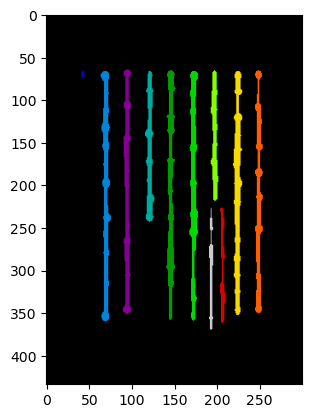

In [3]:
import sys, os 
from matplotlib import pyplot as plt
sys.path.append('../')
from src.my_app.utils.vertical_clustering import VerticalClustering
vertical_clustering = VerticalClustering()

combined_image = vertical_clustering.get_combine_image(
    train_dataset[0][1][0], train_dataset[0][1][1]
)
labels = vertical_clustering.cluster_vertical_columns_adaptive(
    combined_image.cpu().numpy(), thresh=None,
    gap_limit=12,                   # 小さな縦ギャップのみ埋める
    mode="closing",
    vertical_len=25,
    iterations=1,
    # multi_vertical_lens=[10,25,40], # 段階的 (使うときは vertical_len/iterations は無視される)
)
plt.imshow(labels, cmap='nipy_spectral')
plt.show()